# EDA Notebook for Credit Default Data

In [1]:
import os
import re
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', tempfile.mkdtemp(prefix='mpl-config-'))
os.environ.setdefault('XDG_CACHE_HOME', tempfile.mkdtemp(prefix='xdg-cache-'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

RANDOM_STATE = 42
TARGET = 'Credit Default'
DATA_PATH = Path('data/credit-default-data.csv')
NEW_APPS_PATH = Path('data/new-applications.csv')


Matplotlib is building the font cache; this may take a moment.


## Load and Overview

Start with the labeled training data and the unlabeled `new-applications.csv` file so the EDA stays relevant for downstream scoring.

In [2]:
df = pd.read_csv(DATA_PATH)
new_apps = pd.read_csv(NEW_APPS_PATH)

print(f'Training data shape: {df.shape}')
print(f'New applications shape: {new_apps.shape}')

overview = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(dropna=False)
})

display(df.head())
display(overview)


Training data shape: (7500, 18)
New applications shape: (2500, 17)


,Id,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,0,Own Home,"482,087.000",NaN,0.000,11.000,26.300,"685,960.000",1.000,NaN,1.000,debt consolidation,Short Term,"99,999,999.000","47,386.000","7,914.000",749.000,0
1,1,Own Home,"1,025,487.000",10+ years,0.000,15.000,15.300,"1,181,730.000",0.000,NaN,0.000,debt consolidation,Long Term,"264,968.000","394,972.000","18,373.000",737.000,1
2,2,Home Mortgage,"751,412.000",8 years,0.000,11.000,35.000,"1,182,434.000",0.000,NaN,0.000,debt consolidation,Short Term,"99,999,999.000","308,389.000","13,651.000",742.000,0
3,3,Own Home,"805,068.000",6 years,0.000,8.000,22.500,"147,400.000",1.000,NaN,1.000,debt consolidation,Short Term,"121,396.000","95,855.000","11,338.000",694.000,0
4,4,Rent,"776,264.000",8 years,0.000,13.000,13.600,"385,836.000",1.000,NaN,0.000,debt consolidation,Short Term,"125,840.000","93,309.000","7,180.000",719.000,0


,dtype,missing_count,missing_pct,nunique
Id,int64,0,0.000,7500
Home Ownership,object,0,0.000,4
Annual Income,float64,1557,20.760,5479
Years in current job,object,371,4.950,12
Tax Liens,float64,0,0.000,8
Number of Open Accounts,float64,0,0.000,39
Years of Credit History,float64,0,0.000,408
Maximum Open Credit,float64,0,0.000,6963
Number of Credit Problems,float64,0,0.000,8
Months since last delinquent,float64,4081,54.410,90


,train_column,in_new_applications,is_target
0,Id,True,False
1,Home Ownership,True,False
2,Annual Income,True,False
3,Years in current job,True,False
4,Tax Liens,True,False
5,Number of Open Accounts,True,False
6,Years of Credit History,True,False
7,Maximum Open Credit,True,False
8,Number of Credit Problems,True,False
9,Months since last delinquent,True,False


Train-only columns: ['Credit Default']
New-application-only columns: []
Duplicate rows: 0
Duplicate Id values: 0


,Credit Default,share,share_pct
0,0,0.718,71.830
1,1,0.282,28.170


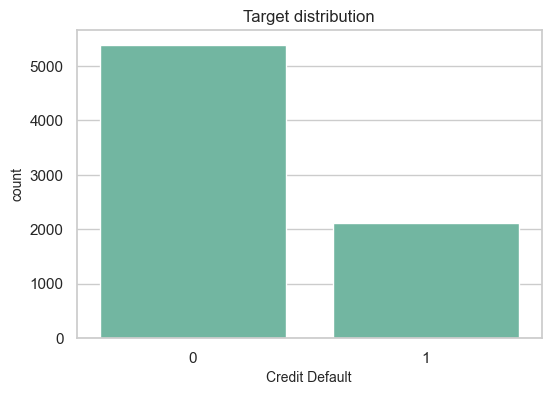

In [3]:
schema_summary = pd.DataFrame({
    'train_column': df.columns,
    'in_new_applications': [col in new_apps.columns for col in df.columns],
    'is_target': [col == TARGET for col in df.columns]
})
display(schema_summary)

train_only = sorted(set(df.columns) - set(new_apps.columns))
new_only = sorted(set(new_apps.columns) - set(df.columns))
print('Train-only columns:', train_only)
print('New-application-only columns:', new_only)
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Id values: {df['Id'].duplicated().sum()}")

class_balance = (
    df[TARGET]
    .value_counts(normalize=True)
    .rename_axis('Credit Default')
    .reset_index(name='share')
)
class_balance['share_pct'] = (class_balance['share'] * 100).round(2)
display(class_balance)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title('Target distribution')
plt.show()


In [4]:
def job_tenure_to_years(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    if value == '< 1 year':
        return 0.5
    if value == '10+ years':
        return 10.0
    match = re.search(r'(\d+)', value)
    return float(match.group(1)) if match else np.nan

def add_clean_features(frame):
    cleaned = frame.copy()
    cleaned['home_ownership_clean'] = cleaned['Home Ownership'].replace({'Have Mortgage': 'Home Mortgage'})
    cleaned['credit_score_clean'] = cleaned['Credit Score'].where(cleaned['Credit Score'] <= 850, cleaned['Credit Score'] / 10)
    cleaned['credit_score_scaled_flag'] = cleaned['Credit Score'].gt(850).fillna(False).astype(int)
    cleaned['loan_amount_placeholder_flag'] = cleaned['Current Loan Amount'].eq(99999999).astype(int)
    cleaned['current_loan_amount_clean'] = cleaned['Current Loan Amount'].mask(cleaned['loan_amount_placeholder_flag'].eq(1))
    cleaned['job_tenure_years'] = cleaned['Years in current job'].apply(job_tenure_to_years)
    cleaned['income_missing_flag'] = cleaned['Annual Income'].isna().astype(int)
    cleaned['credit_score_missing_flag'] = cleaned['Credit Score'].isna().astype(int)
    cleaned['delinquency_missing_flag'] = cleaned['Months since last delinquent'].isna().astype(int)
    annual_income_monthly = cleaned['Annual Income'] / 12
    cleaned['monthly_dti'] = cleaned['Monthly Debt'] / annual_income_monthly.replace(0, np.nan)
    cleaned['credit_utilization_proxy'] = cleaned['Current Credit Balance'] / cleaned['Maximum Open Credit'].replace(0, np.nan)
    cleaned['loan_to_income_ratio'] = cleaned['current_loan_amount_clean'] / cleaned['Annual Income']
    return cleaned

def default_rate_table(frame, column):
    temp = frame[[column, TARGET]].copy()
    if temp[column].dtype == 'O':
        temp[column] = temp[column].fillna('Missing')
    grouped = (
        temp.groupby(column, dropna=False)[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
        .sort_values(['default_rate', 'count'], ascending=[False, False])
    )
    return grouped

def show_categorical_profile(frame, column):
    plot_df = frame[[column, TARGET]].copy()
    plot_df[column] = plot_df[column].fillna('Missing')
    summary = (
        plot_df.groupby(column)[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
        .sort_values(['default_rate', 'count'], ascending=[False, False])
    )
    display(summary)

    order = summary[column].tolist()
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.countplot(data=plot_df, y=column, order=order, ax=axes[0])
    axes[0].set_title(f'{column}: volume')
    axes[0].set_xlabel('count')

    sns.barplot(data=summary, y=column, x='default_rate', order=order, ax=axes[1], color=sns.color_palette('Set2')[0])
    axes[1].set_title(f'{column}: default rate')
    axes[1].set_xlabel('default rate')
    plt.tight_layout()
    plt.show()

def show_missingness_impact(frame, column):
    plot_df = frame[[column, TARGET]].copy()
    plot_df['missing_status'] = np.where(plot_df[column].isna(), 'Missing', 'Present')
    summary = (
        plot_df.groupby('missing_status')[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
    )
    display(summary)

    plt.figure(figsize=(6, 4))
    sns.barplot(data=summary, x='missing_status', y='default_rate', color=sns.color_palette('Set2')[1])
    plt.title(f'{column}: default rate by missingness')
    plt.ylabel('default rate')
    plt.show()

def show_numeric_profile(frame, column, clip_quantile=0.99):
    plot_df = frame[[column, TARGET]].dropna().copy()
    if plot_df.empty:
        print(f'No non-null values available for {column}.')
        return

    plot_df['target_label'] = plot_df[TARGET].map({0: 'Non-default', 1: 'Default'})
    upper = plot_df[column].quantile(clip_quantile)
    plot_df['feature_clipped'] = plot_df[column].clip(upper=upper)

    summary = (
        plot_df.groupby('target_label')[column]
        .agg(['count', 'mean', 'median'])
        .round(3)
    )
    display(summary)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(
        data=plot_df,
        x='feature_clipped',
        hue='target_label',
        bins=30,
        stat='density',
        common_norm=False,
        element='step',
        ax=axes[0]
    )
    axes[0].set_title(f'{column}: distribution clipped at {int(clip_quantile * 100)}th percentile')
    axes[0].set_xlabel(column)

    sns.boxplot(data=plot_df, x='target_label', y='feature_clipped', ax=axes[1])
    axes[1].set_title(f'{column}: target split boxplot')
    axes[1].set_xlabel('target')
    axes[1].set_ylabel(column)

    plt.tight_layout()
    plt.show()

def show_binned_default_rate(frame, column, bins=5, clip_quantile=None):
    plot_df = frame[[column, TARGET]].dropna().copy()
    if plot_df[column].nunique() < 2:
        print(f'Not enough variation to bin {column}.')
        return

    series_to_bin = plot_df[column].copy()
    if clip_quantile is not None:
        upper = series_to_bin.quantile(clip_quantile)
        series_to_bin = series_to_bin.clip(upper=upper)

    plot_df['feature_bin'] = pd.qcut(series_to_bin, q=bins, duplicates='drop')
    summary = (
        plot_df.groupby('feature_bin', observed=False)[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
    )
    display(summary)

    plt.figure(figsize=(10, 4))
    sns.barplot(data=summary, x='feature_bin', y='default_rate', color=sns.color_palette('Set2')[2])
    plt.title(f'{column}: default rate across quantile bins')
    plt.xticks(rotation=30, ha='right')
    plt.ylabel('default rate')
    plt.xlabel('bin')
    plt.tight_layout()
    plt.show()

eda_df = add_clean_features(df)
new_apps_clean = add_clean_features(new_apps)


## Data Quality Audit

This section checks whether fields are reliable borrower signals, raw operational artifacts, or columns that need explicit handling before any importance judgment is made.

In [5]:
quality_audit = pd.DataFrame({
    'dtype': eda_df.dtypes.astype(str),
    'missing_count': eda_df.isna().sum(),
    'missing_pct': (eda_df.isna().mean() * 100).round(2),
    'nunique': eda_df.nunique(dropna=False)
}).sort_values(['missing_pct', 'nunique'], ascending=[False, False])
display(quality_audit)

key_audit_metrics = pd.DataFrame({
    'metric': [
        'Unique Id values',
        'Rows with Annual Income missing',
        'Rows with Credit Score missing',
        'Rows with both Annual Income and Credit Score missing',
        'Rows with Current Loan Amount placeholder 99,999,999',
        'Rows with raw Credit Score above 850',
        'Rows with Have Mortgage label',
        'Rows with Months since last delinquent missing'
    ],
    'value': [
        int(df['Id'].nunique()),
        int(df['Annual Income'].isna().sum()),
        int(df['Credit Score'].isna().sum()),
        int((df['Annual Income'].isna() & df['Credit Score'].isna()).sum()),
        int(eda_df['loan_amount_placeholder_flag'].sum()),
        int(eda_df['credit_score_scaled_flag'].sum()),
        int((df['Home Ownership'] == 'Have Mortgage').sum()),
        int(df['Months since last delinquent'].isna().sum())
    ]
})
display(key_audit_metrics)


,dtype,missing_count,missing_pct,nunique
Months since last delinquent,float64,4081,54.410,90
loan_to_income_ratio,float64,2427,32.360,4533
monthly_dti,float64,1557,20.760,5936
Annual Income,float64,1557,20.760,5479
Credit Score,float64,1557,20.760,269
credit_score_clean,float64,1557,20.760,161
current_loan_amount_clean,float64,870,11.600,5386
Years in current job,object,371,4.950,12
job_tenure_years,float64,371,4.950,12
credit_utilization_proxy,float64,65,0.870,7416


,metric,value
0,Unique Id values,7500
1,Rows with Annual Income missing,1557
2,Rows with Credit Score missing,1557
3,Rows with both Annual Income and Credit Score ...,1557
4,"Rows with Current Loan Amount placeholder 99,9...",870
5,Rows with raw Credit Score above 850,400
6,Rows with Have Mortgage label,12
7,Rows with Months since last delinquent missing,4081


,feature,present_default_rate,missing_default_rate,missing_share
0,Annual Income,0.267,0.340,0.208
1,Credit Score,0.267,0.340,0.208
2,Years in current job,0.277,0.369,0.049
3,Months since last delinquent,0.288,0.277,0.544


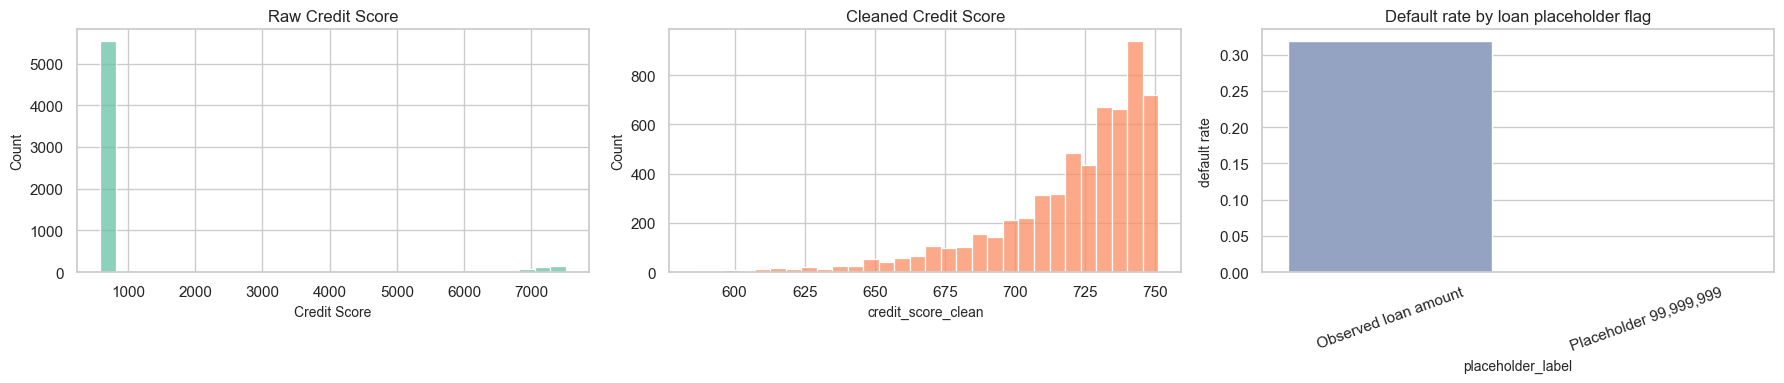

In [6]:
missingness_vs_target = pd.DataFrame([
    {
        'feature': col,
        'present_default_rate': eda_df.loc[eda_df[col].notna(), TARGET].mean(),
        'missing_default_rate': eda_df.loc[eda_df[col].isna(), TARGET].mean(),
        'missing_share': eda_df[col].isna().mean()
    }
    for col in ['Annual Income', 'Credit Score', 'Years in current job', 'Months since last delinquent']
]).round(3)
display(missingness_vs_target)

placeholder_summary = (
    eda_df.assign(
        placeholder_label=np.where(
            eda_df['loan_amount_placeholder_flag'].eq(1),
            'Placeholder 99,999,999',
            'Observed loan amount'
        )
    )
    .groupby('placeholder_label')[TARGET]
    .mean()
    .reset_index(name='default_rate')
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(data=eda_df, x='Credit Score', bins=30, ax=axes[0], color=sns.color_palette('Set2')[0])
axes[0].set_title('Raw Credit Score')
sns.histplot(data=eda_df, x='credit_score_clean', bins=30, ax=axes[1], color=sns.color_palette('Set2')[1])
axes[1].set_title('Cleaned Credit Score')
sns.barplot(data=placeholder_summary, x='placeholder_label', y='default_rate', ax=axes[2], color=sns.color_palette('Set2')[2])
axes[2].set_title('Default rate by loan placeholder flag')
axes[2].set_ylabel('default rate')
axes[2].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()


## Business Meaning by Column

### Administrative
- `Id`: application identifier for audit trails and joins; unique in every row; should be excluded from predictive modeling.

### Stability
- `Home Ownership`: proxy for housing stability and wealth buffer; likely useful but needs normalization from `Have Mortgage` to `Home Mortgage`; fairness review is important because it can proxy socioeconomic status.
- `Years in current job`: proxy for employment stability and income persistence; useful once parsed into ordered tenure; missingness may itself signal weaker documentation quality.

### Affordability
- `Annual Income`: core repayment-capacity variable; high business value; missing together with `Credit Score` suggests upstream information gaps; useful for debt-to-income and loan-to-income features.
- `Monthly Debt`: recurring debt burden; important for affordability screening; strong candidate for a normalized debt-to-income ratio instead of raw use alone.
- `Current Loan Amount`: requested exposure amount; economically important, but the `99,999,999` placeholder looks like a process artifact and should never be trusted raw.

### Credit Capacity and Leverage
- `Maximum Open Credit`: credit capacity proxy; useful with balance to estimate utilization; extremely skewed, so distribution-aware analysis matters.
- `Current Credit Balance`: current revolving or outstanding balance proxy; useful for leverage and utilization; likely stronger when normalized by maximum open credit.
- `Number of Open Accounts`: breadth of active credit relationships; can reflect both maturity and leverage; likely moderate signal.

### Credit Behavior and Bureau Risk
- `Credit Score`: high-value bureau summary metric; raw field mixes normal and scaled values, so only a cleaned version is reliable for EDA and downstream use.
- `Number of Credit Problems`: captures past credit trouble; likely interpretable and useful, though low-frequency values should be monitored.
- `Tax Liens`: serious adverse public-record style indicator; economically meaningful but sparse, so signal may be sharp for a small subgroup.
- `Bankruptcies`: strong distress indicator when present; low missingness, but values are heavily concentrated at zero.
- `Months since last delinquent`: recency of bad payment behavior; business-relevant, but more than half the rows are missing, so the missingness must stay explicit.
- `Years of Credit History`: borrower credit maturity and experience; usually stabilizes risk interpretation when read with account counts and utilization.

### Product and Intent
- `Purpose`: loan-use intent; useful for segmentation because business loans, consolidation, or discretionary uses can behave differently.
- `Term`: short-term versus long-term structure; business-important because longer duration often changes both risk and economics.

### Label
- `Credit Default`: target variable only; not a feature.

## Univariate and Target-Focused EDA

These plots focus on how borrower profiles differ between default and non-default outcomes, while clipping extreme outliers for more readable visuals.

### Annual Income

,count,mean,median
target_label,,,
Default,1584,"1,224,242.953","1,055,915.500"
Non-default,4359,"1,418,046.606","1,225,747.000"


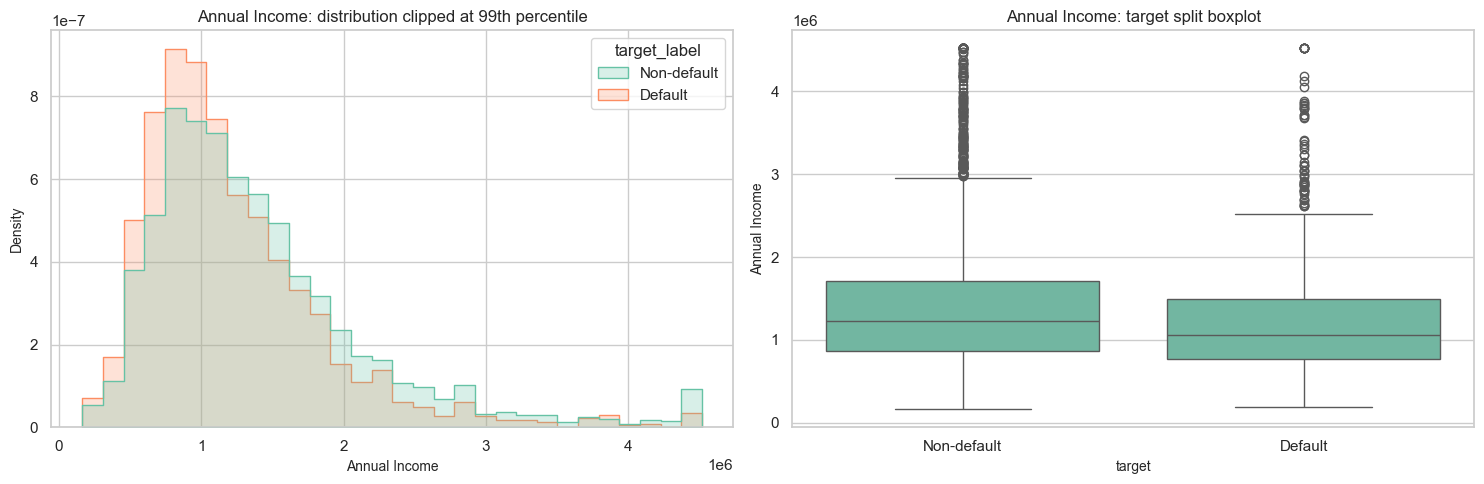

### Monthly Debt

,count,mean,median
target_label,,,
Default,2113,"18,666.352","16,390.000"
Non-default,5387,"18,176.425","15,939.000"


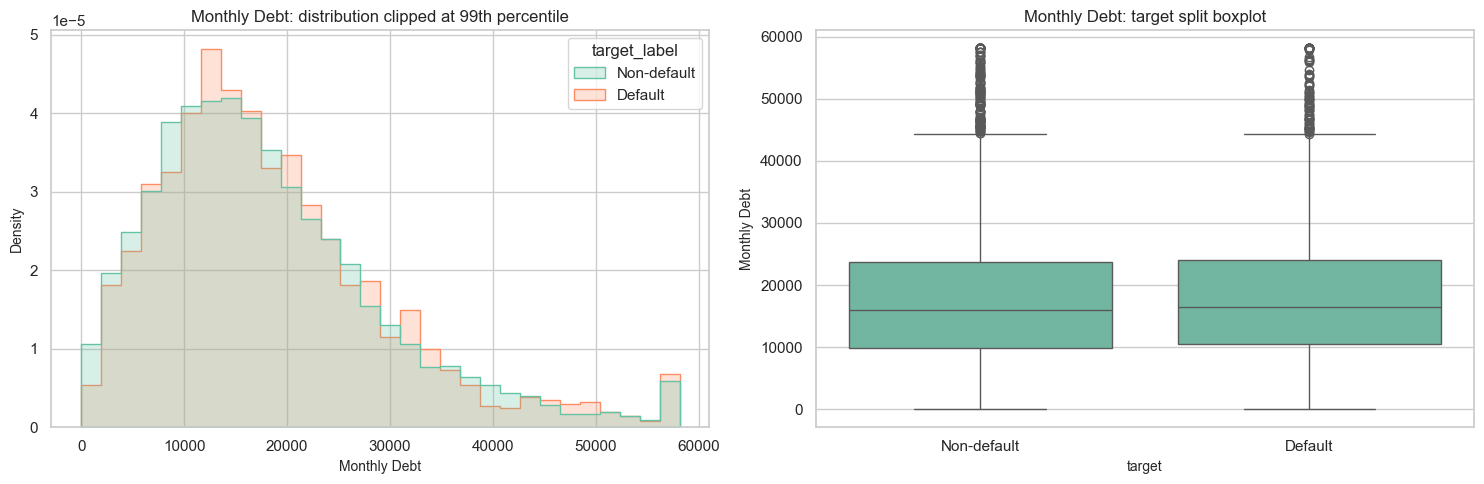

### Current Credit Balance

,count,mean,median
target_label,,,
Default,2113,"279,925.570","210,102.000"
Non-default,5387,"293,719.423","209,285.000"


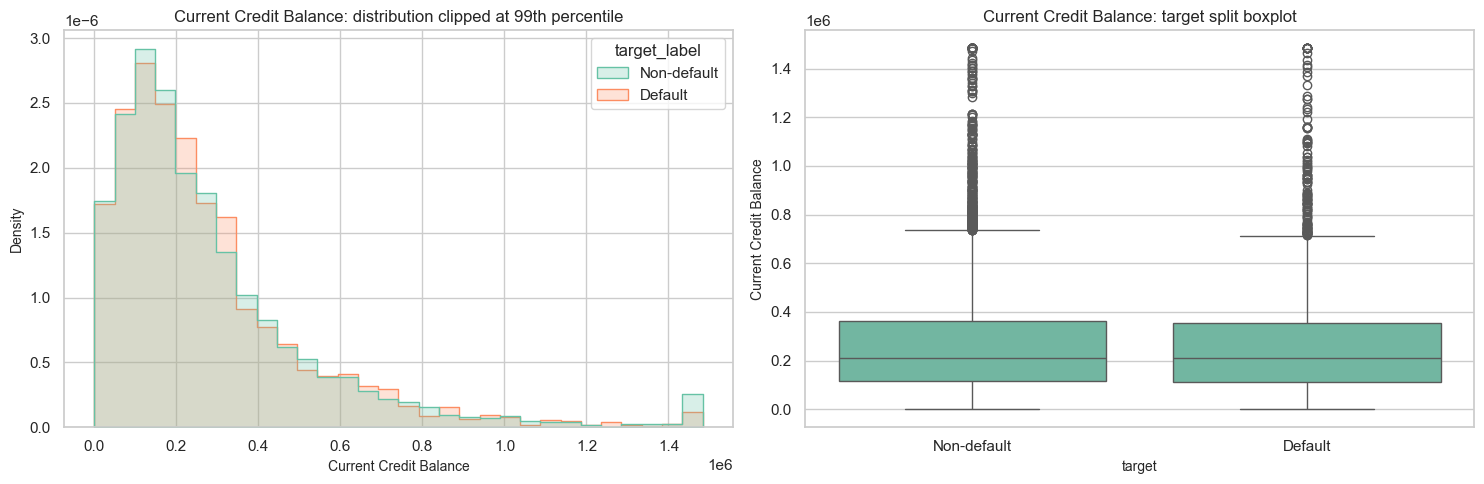

### Maximum Open Credit

,count,mean,median
target_label,,,
Default,2113,"579,898.156","442,090.000"
Non-default,5387,"1,088,421.784","493,746.000"


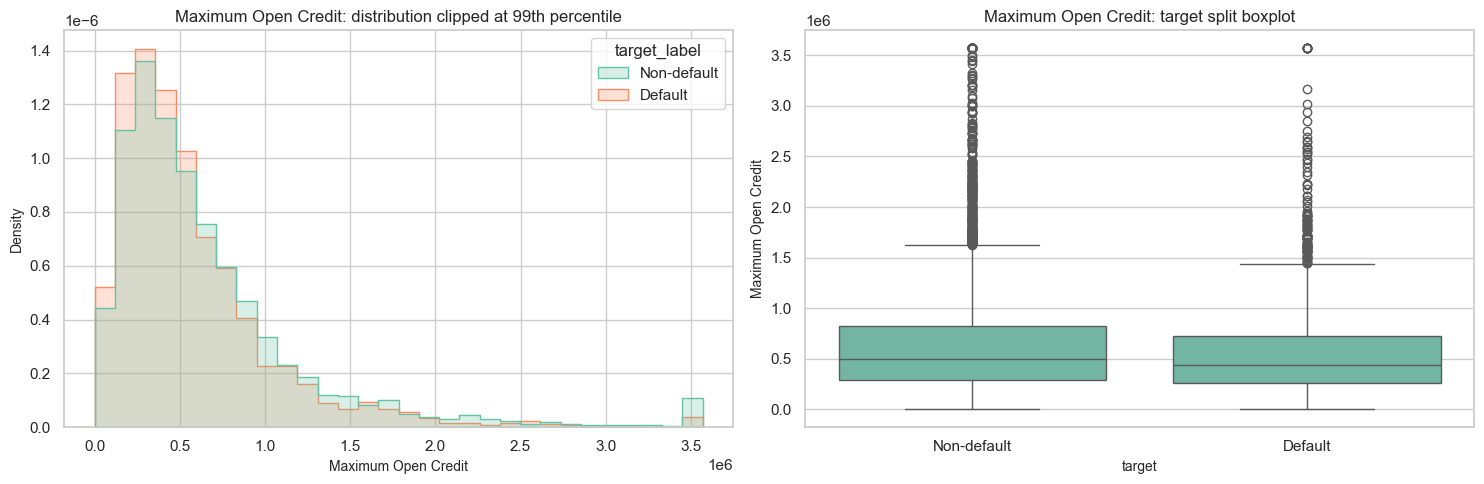

### Years of Credit History

,count,mean,median
target_label,,,
Default,2113,18.086,16.700
Non-default,5387,18.408,17.100


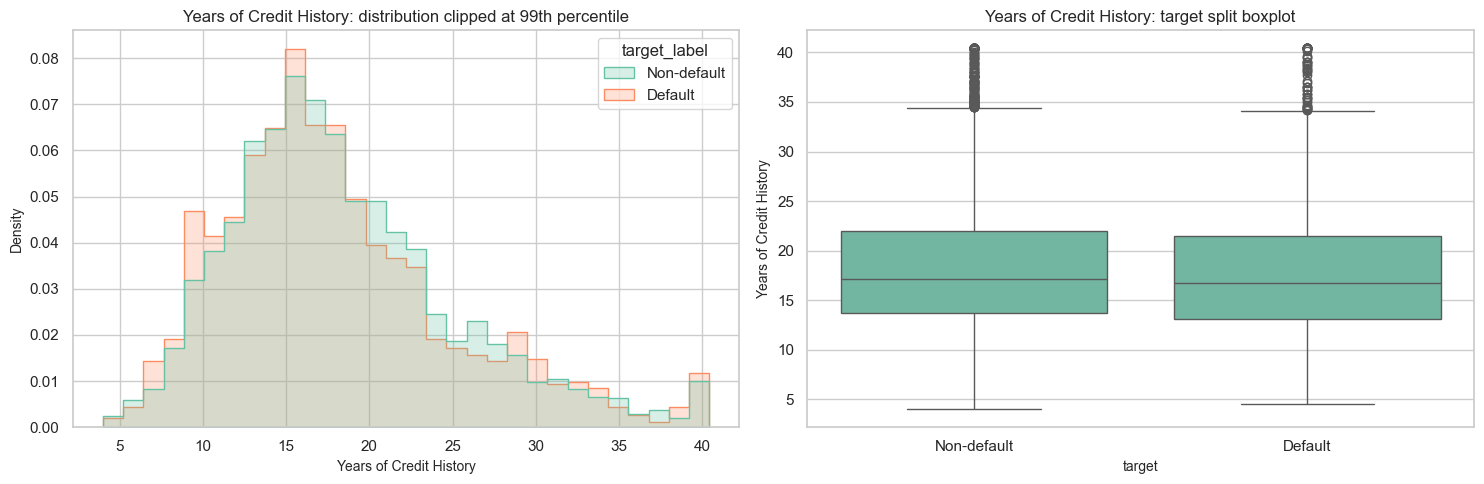

### credit_score_clean

,count,mean,median
target_label,,,
Default,1584,710.480,720.000
Non-default,4359,723.578,732.000


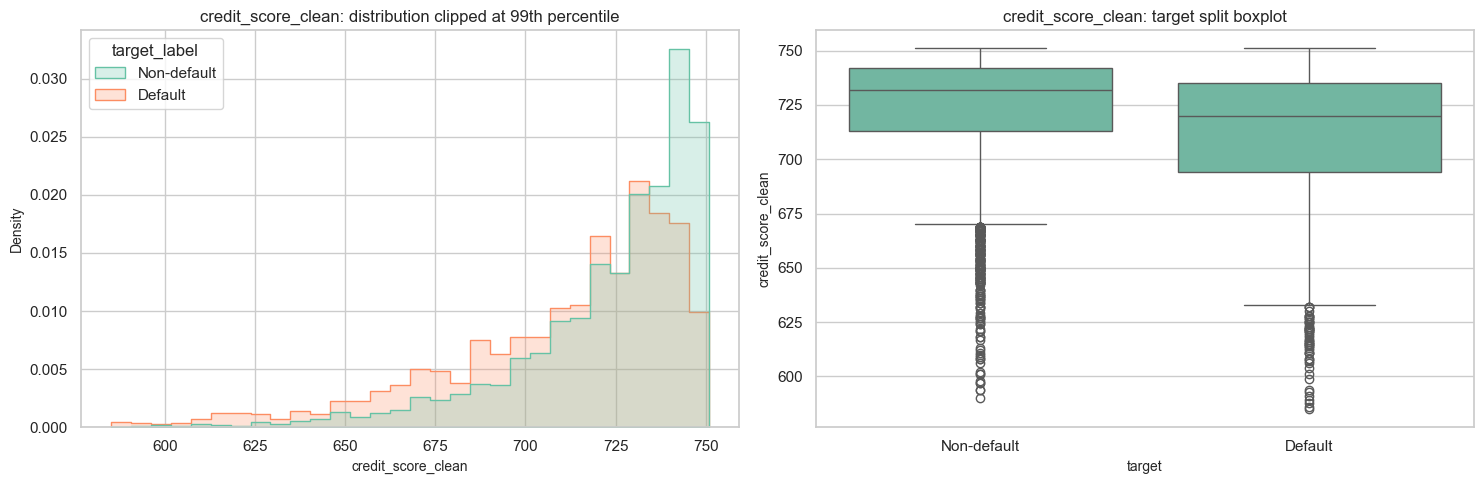

### current_loan_amount_clean

,count,mean,median
target_label,,,
Default,2113,"326,651.044","290,576.000"
Non-default,4517,"300,778.847","262,482.000"


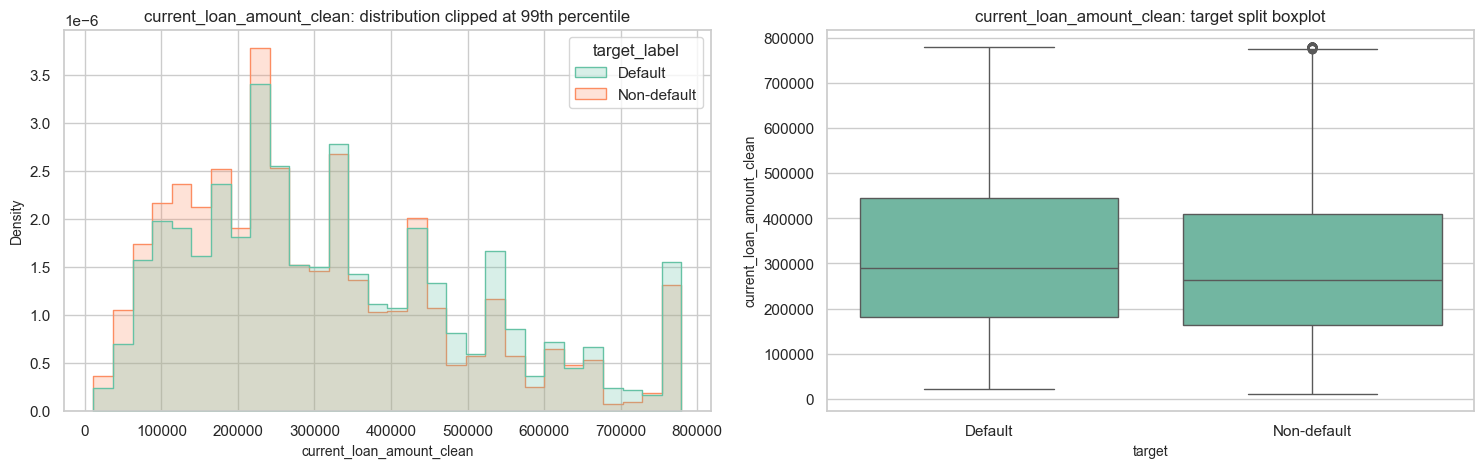

In [8]:
raw_numeric_focus = [
    'Annual Income',
    'Monthly Debt',
    'Current Credit Balance',
    'Maximum Open Credit',
    'Years of Credit History',
    'credit_score_clean',
    'current_loan_amount_clean'
]

for column in raw_numeric_focus:
    display(Markdown(f'### {column}'))
    show_numeric_profile(eda_df, column)


### home_ownership_clean

,home_ownership_clean,count,default_rate
2,Rent,3204,0.313
1,Own Home,647,0.297
0,Home Mortgage,3649,0.252


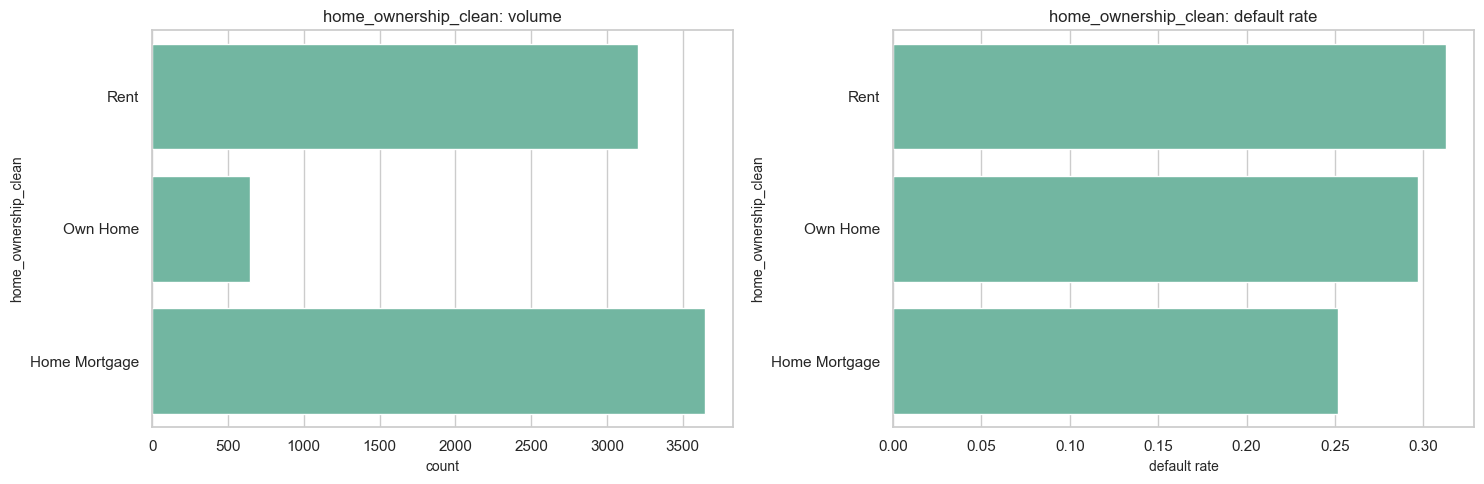

### Years in current job

,Years in current job,count,default_rate
11,Missing,371,0.369
6,6 years,426,0.291
10,< 1 year,563,0.282
0,1 year,504,0.282
5,5 years,516,0.281
7,7 years,396,0.280
4,4 years,469,0.279
1,10+ years,2332,0.276
3,3 years,620,0.274
2,2 years,705,0.274


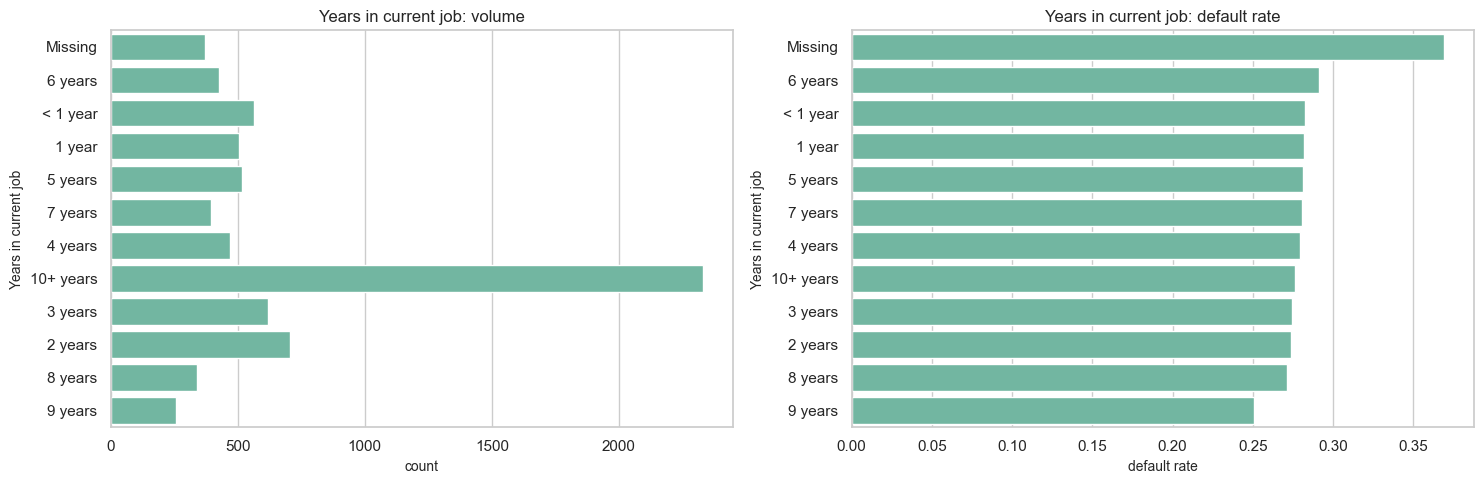

### Purpose

,Purpose,count,default_rate
10,renewable energy,2,1.000
11,small business,26,0.538
0,business loan,129,0.426
7,medical bills,71,0.310
9,other,665,0.296
3,debt consolidation,5944,0.278
12,take a trip,37,0.270
14,wedding,15,0.267
2,buy house,34,0.265
5,home improvements,412,0.262


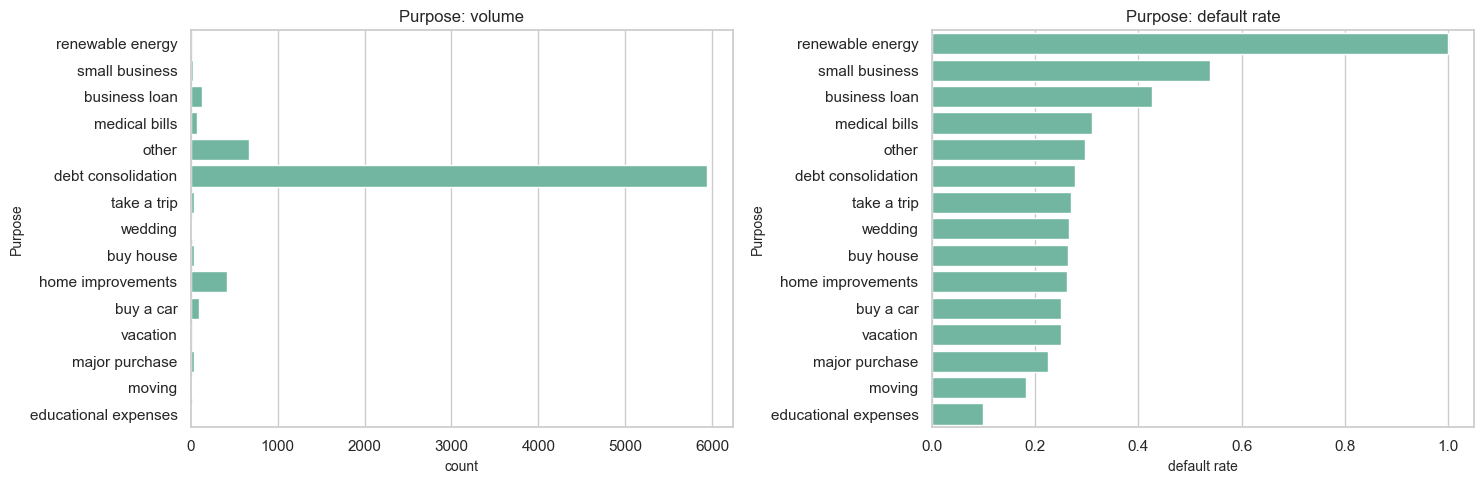

### Term

,Term,count,default_rate
0,Long Term,1944,0.420
1,Short Term,5556,0.233


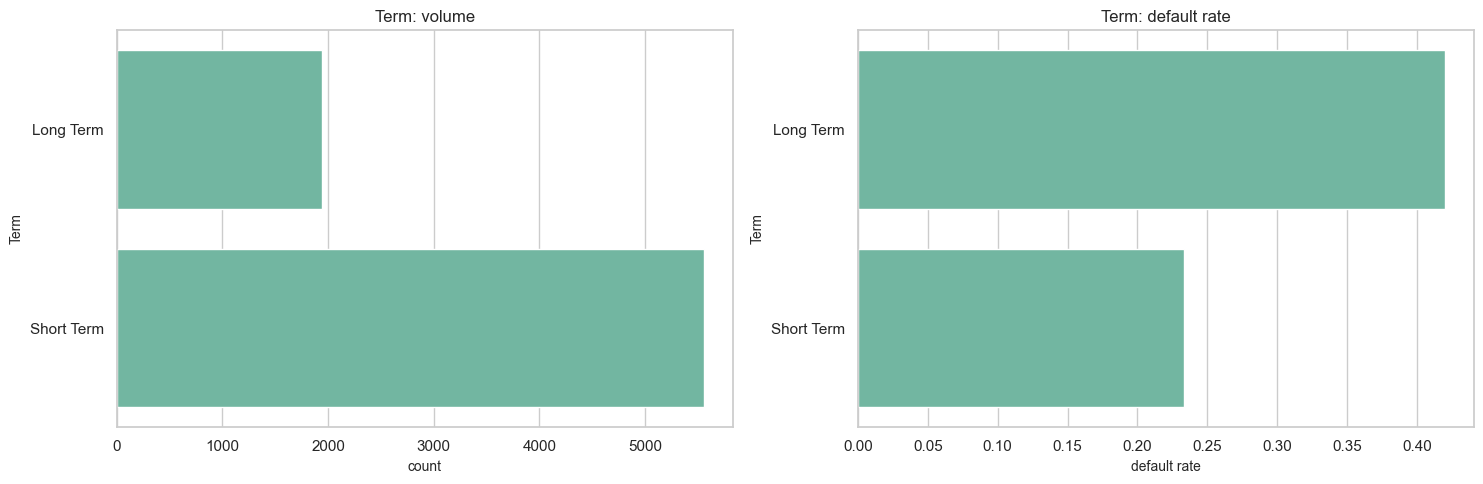

In [9]:
for column in ['home_ownership_clean', 'Years in current job', 'Purpose', 'Term']:
    display(Markdown(f'### {column}'))
    show_categorical_profile(eda_df, column)


In [ ]:
for column in ['Annual Income', 'Credit Score', 'Years in current job', 'Months since last delinquent']:
    display(Markdown(f'### Missingness impact: {column}'))
    show_missingness_impact(eda_df, column)


## Feature Engineering EDA

The next step is to convert business intuition into concrete candidate features. These are still exploratory features, not a final production feature list.

In [11]:
derived_feature_dictionary = pd.DataFrame({
    'derived_feature': [
        'credit_score_clean',
        'loan_amount_placeholder_flag',
        'current_loan_amount_clean',
        'job_tenure_years',
        'monthly_dti',
        'credit_utilization_proxy',
        'loan_to_income_ratio',
        'income_missing_flag',
        'credit_score_missing_flag',
        'delinquency_missing_flag'
    ],
    'business_reason': [
        'Fix mixed-scale bureau score values before importance analysis.',
        'Preserve the placeholder pattern separately from the numeric amount.',
        'Use a cleaned requested amount without the 99,999,999 artifact.',
        'Turn job-tenure text into ordered numeric stability signal.',
        'Normalize monthly debt by monthly income to capture affordability stress.',
        'Approximate revolving credit utilization using current balance and open credit.',
        'Scale requested amount by income to estimate repayment stretch.',
        'Retain operational missingness for income as its own signal.',
        'Retain operational missingness for credit score as its own signal.',
        'Keep delinquency-information availability explicit instead of hidden by imputation.'
    ],
    'non_null_count': [eda_df[col].notna().sum() for col in [
        'credit_score_clean',
        'loan_amount_placeholder_flag',
        'current_loan_amount_clean',
        'job_tenure_years',
        'monthly_dti',
        'credit_utilization_proxy',
        'loan_to_income_ratio',
        'income_missing_flag',
        'credit_score_missing_flag',
        'delinquency_missing_flag'
    ]]
})

display(derived_feature_dictionary)
display(eda_df[[
    'credit_score_clean',
    'loan_amount_placeholder_flag',
    'current_loan_amount_clean',
    'job_tenure_years',
    'monthly_dti',
    'credit_utilization_proxy',
    'loan_to_income_ratio',
    'income_missing_flag',
    'credit_score_missing_flag',
    'delinquency_missing_flag',
    TARGET
]].head())


,derived_feature,business_reason,non_null_count
0,credit_score_clean,Fix mixed-scale bureau score values before imp...,5943
1,loan_amount_placeholder_flag,Preserve the placeholder pattern separately fr...,7500
2,current_loan_amount_clean,"Use a cleaned requested amount without the 99,...",6630
3,job_tenure_years,Turn job-tenure text into ordered numeric stab...,7129
4,monthly_dti,Normalize monthly debt by monthly income to ca...,5943
5,credit_utilization_proxy,Approximate revolving credit utilization using...,7435
6,loan_to_income_ratio,Scale requested amount by income to estimate r...,5073
7,income_missing_flag,Retain operational missingness for income as i...,7500
8,credit_score_missing_flag,Retain operational missingness for credit scor...,7500
9,delinquency_missing_flag,Keep delinquency-information availability expl...,7500


,credit_score_clean,loan_amount_placeholder_flag,current_loan_amount_clean,job_tenure_years,monthly_dti,credit_utilization_proxy,loan_to_income_ratio,income_missing_flag,credit_score_missing_flag,delinquency_missing_flag,Credit Default
0,749.000,1,NaN,NaN,0.197,0.069,NaN,0,0,1,0
1,737.000,0,"264,968.000",10.000,0.215,0.334,0.258,0,0,1,1
2,742.000,1,NaN,8.000,0.218,0.261,NaN,0,0,1,0
3,694.000,0,"121,396.000",6.000,0.169,0.650,0.151,0,0,1,0
4,719.000,0,"125,840.000",8.000,0.111,0.242,0.162,0,0,1,0


### credit_score_clean

,feature_bin,count,default_rate
0,"(584.999, 702.0]",1224,0.407
1,"(702.0, 722.0]",1202,0.292
2,"(722.0, 734.0]",1194,0.278
3,"(734.0, 742.0]",1156,0.218
4,"(742.0, 751.0]",1167,0.129


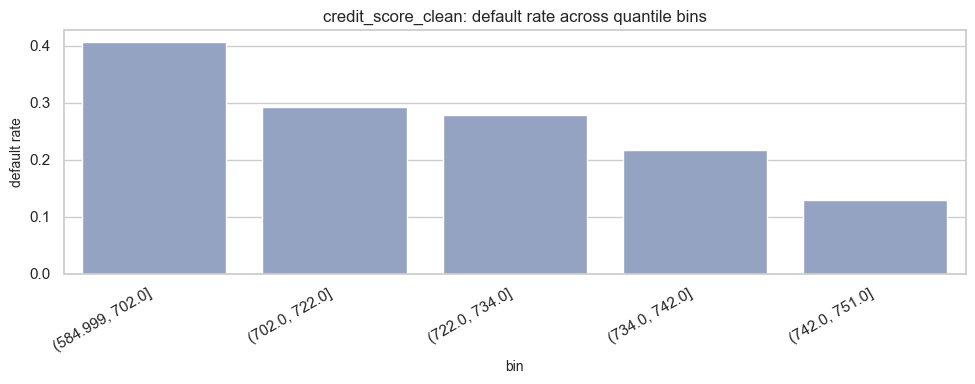

### job_tenure_years

,feature_bin,count,default_rate
0,"(0.499, 2.0]",1772,0.279
1,"(2.0, 4.0]",1089,0.276
2,"(4.0, 8.0]",1677,0.281
3,"(8.0, 10.0]",2591,0.274


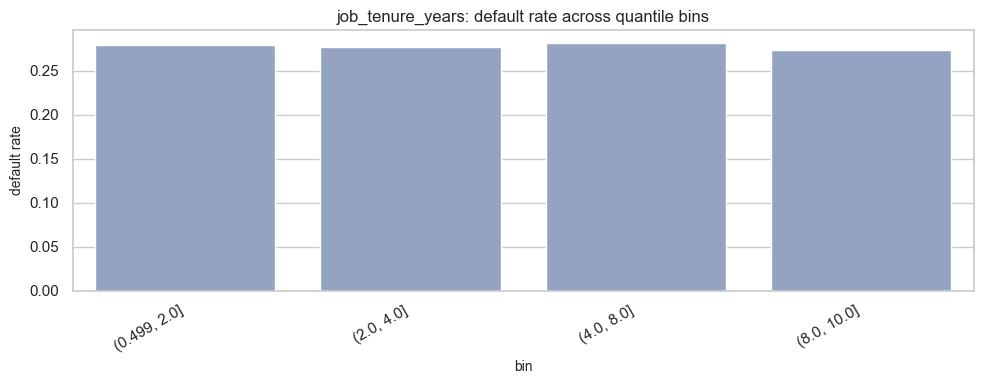

### monthly_dti

,feature_bin,count,default_rate
0,"(-0.001, 0.098]",1189,0.181
1,"(0.098, 0.146]",1188,0.232
2,"(0.146, 0.189]",1189,0.272
3,"(0.189, 0.241]",1188,0.292
4,"(0.241, 0.345]",1189,0.356


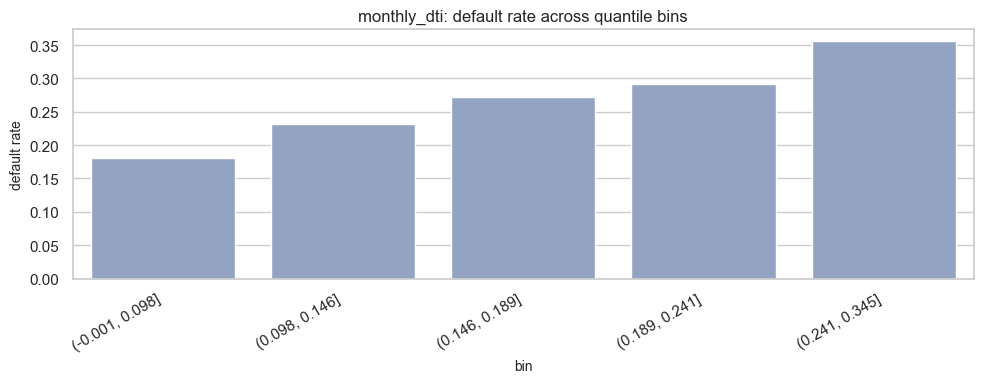

### credit_utilization_proxy

,feature_bin,count,default_rate
0,"(-0.00015700000000000002, 0.283]",1487,0.217
1,"(0.283, 0.429]",1487,0.272
2,"(0.429, 0.548]",1487,0.290
3,"(0.548, 0.673]",1487,0.309
4,"(0.673, 0.844]",1487,0.327


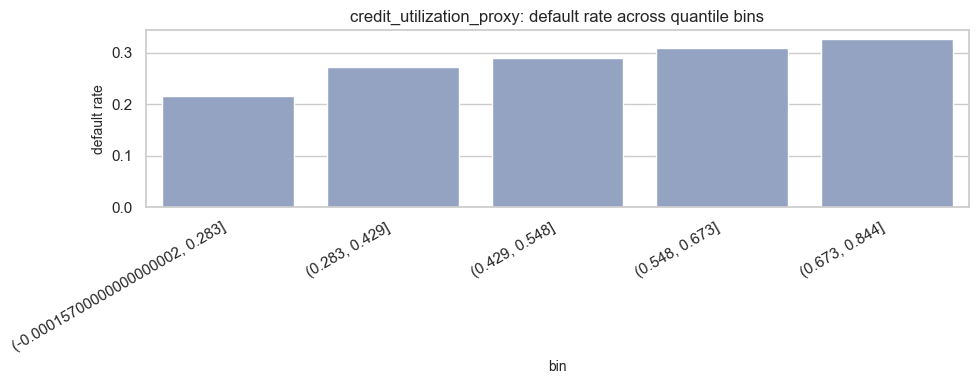

### loan_to_income_ratio

,feature_bin,count,default_rate
0,"(0.008650000000000001, 0.137]",1015,0.226
1,"(0.137, 0.207]",1014,0.285
2,"(0.207, 0.274]",1015,0.272
3,"(0.274, 0.371]",1014,0.348
4,"(0.371, 0.553]",1015,0.431


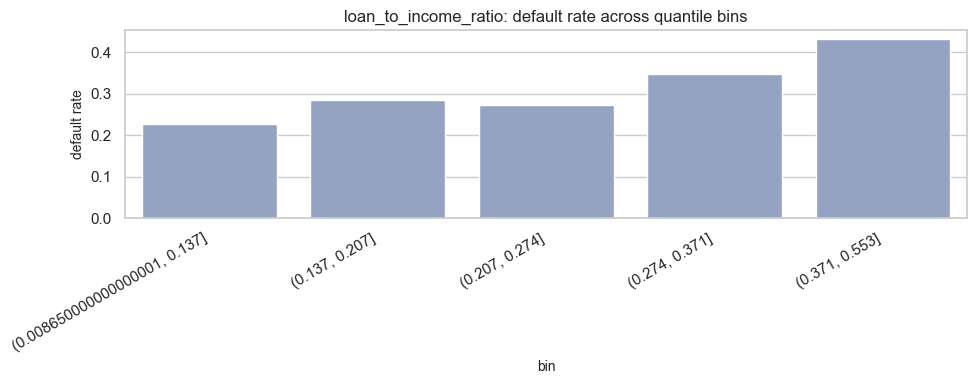

### loan_amount_placeholder_flag

,loan_amount_placeholder_flag,count,default_rate
0,0,6630,0.319
1,1,870,0.000


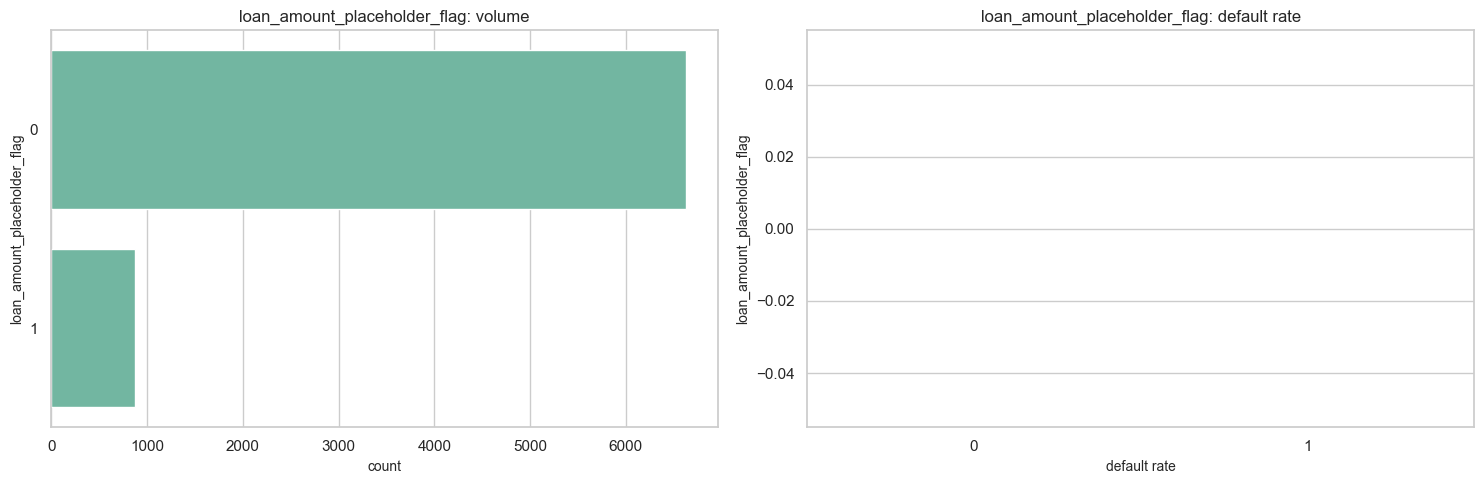

### income_missing_flag

,income_missing_flag,count,default_rate
1,1,1557,0.340
0,0,5943,0.267


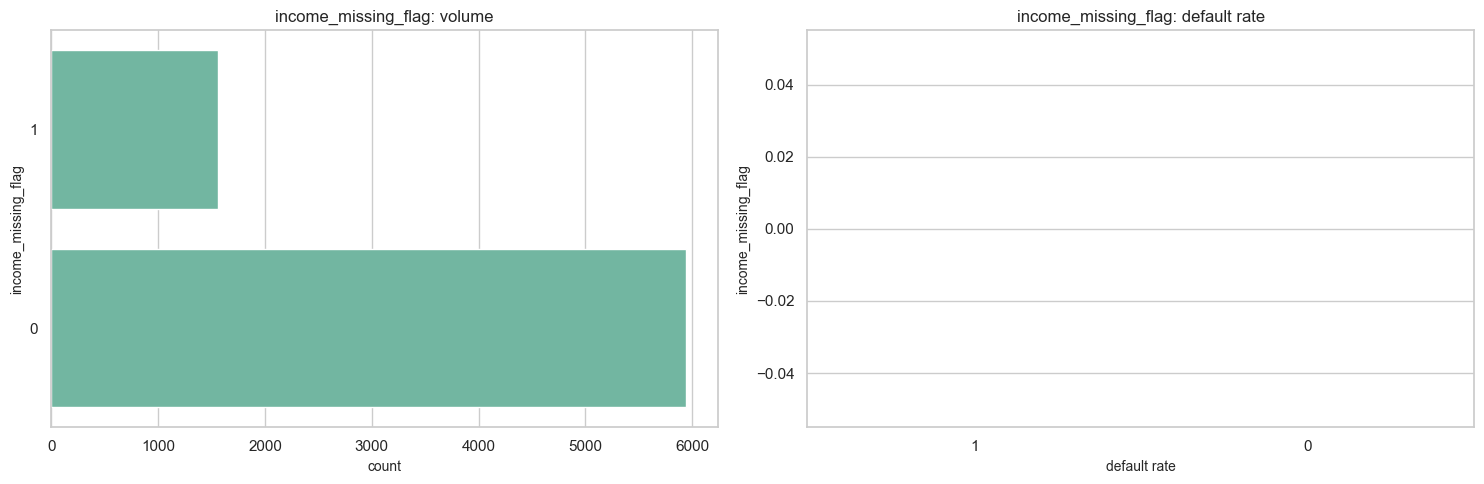

### credit_score_missing_flag

,credit_score_missing_flag,count,default_rate
1,1,1557,0.340
0,0,5943,0.267


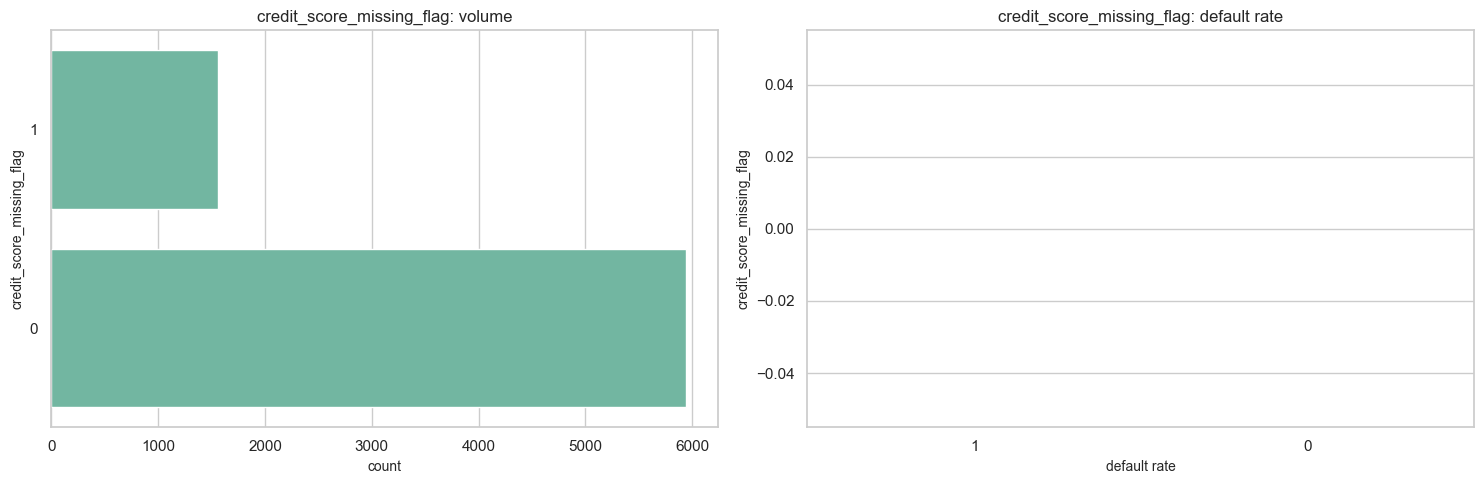

### delinquency_missing_flag

,delinquency_missing_flag,count,default_rate
0,0,3419,0.288
1,1,4081,0.277


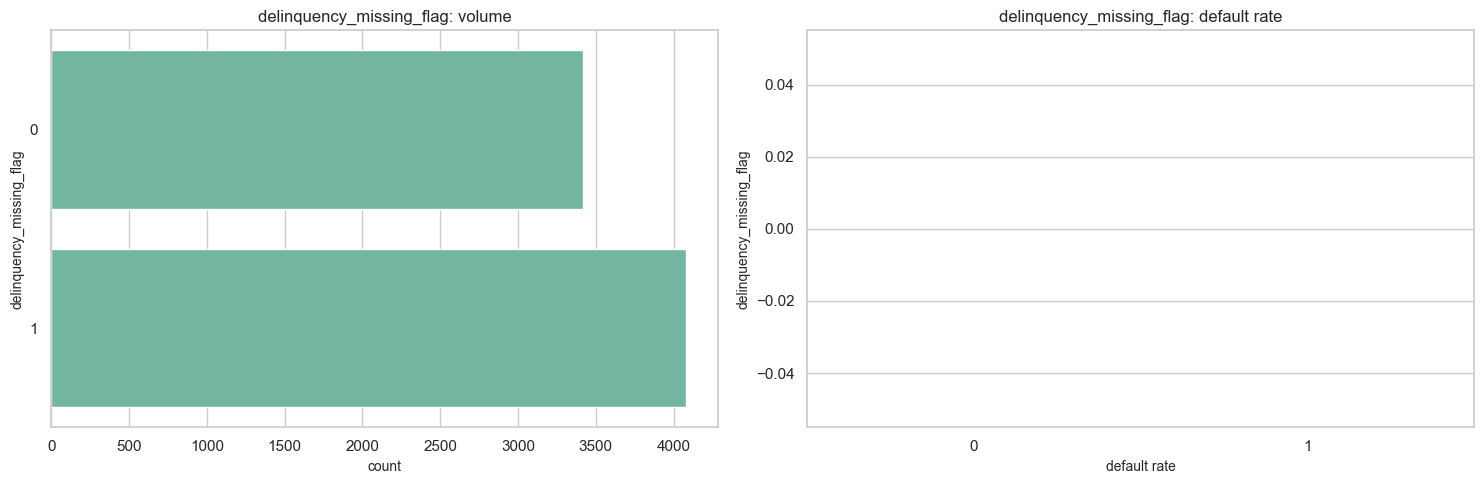

In [12]:
for column in ['credit_score_clean', 'job_tenure_years', 'monthly_dti', 'credit_utilization_proxy', 'loan_to_income_ratio']:
    display(Markdown(f'### {column}'))
    show_binned_default_rate(eda_df, column, clip_quantile=0.99)

for column in ['loan_amount_placeholder_flag', 'income_missing_flag', 'credit_score_missing_flag', 'delinquency_missing_flag']:
    display(Markdown(f'### {column}'))
    show_categorical_profile(eda_df, column)


## Cross-Feature Analysis and Business Interactions

Single variables rarely tell the full credit story on their own. In lending, default risk often becomes much sharper when repayment burden, loan structure, borrower stability, and product intent are evaluated together. This section looks at a small set of business-relevant interactions so we can decide which combinations are useful for feature engineering, segmentation, or policy design.

In [ ]:
def summarize_categorical_interaction(frame, row_col, col_col, min_count=20):
    summary = (
        frame[[row_col, col_col, TARGET]]
        .dropna()
        .groupby([row_col, col_col], observed=False)[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
    )
    summary['small_sample_flag'] = summary['count'] < min_count
    return summary

def summarize_binned_numeric_interaction(frame, numeric_col, categorical_col, bins=4, clip_quantile=0.99, min_count=20):
    plot_df = frame[[numeric_col, categorical_col, TARGET]].dropna().copy()
    if plot_df.empty:
        return pd.DataFrame()
    clipped = plot_df[numeric_col].clip(upper=plot_df[numeric_col].quantile(clip_quantile))
    bin_col = f'{numeric_col}_bin'
    plot_df[bin_col] = pd.qcut(clipped, q=bins, duplicates='drop')
    summary = (
        plot_df.groupby([bin_col, categorical_col], observed=False)[TARGET]
        .agg(['count', 'mean'])
        .reset_index()
        .rename(columns={'mean': 'default_rate'})
    )
    summary['small_sample_flag'] = summary['count'] < min_count
    return summary

def plot_interaction_heatmap(summary, row_col, col_col, title, figsize=(10, 5)):
    if summary.empty:
        print('No data available for this interaction.')
        return
    rate_pivot = summary.pivot(index=row_col, columns=col_col, values='default_rate')
    count_pivot = summary.pivot(index=row_col, columns=col_col, values='count')
    annot = count_pivot.copy().astype(object)
    for row in rate_pivot.index:
        for col in rate_pivot.columns:
            rate = rate_pivot.loc[row, col]
            count = count_pivot.loc[row, col]
            annot.loc[row, col] = '' if pd.isna(rate) else f'{rate:.2f}\n(n={int(count)})'
    plt.figure(figsize=figsize)
    sns.heatmap(rate_pivot, annot=annot, fmt='', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'default rate'})
    plt.title(title)
    plt.ylabel(row_col)
    plt.xlabel(col_col)
    plt.tight_layout()
    plt.show()


In [ ]:
display(Markdown('### 1. `Term x Purpose`'))
display(Markdown('**Business question:** Are some loan purposes much riskier when the loan is long-term?'))
term_purpose_summary = summarize_categorical_interaction(eda_df, 'Purpose', 'Term')
display(term_purpose_summary.sort_values(['default_rate', 'count'], ascending=[False, False]).head(15))
plot_interaction_heatmap(term_purpose_summary, 'Purpose', 'Term', 'Default rate by Purpose and Term', figsize=(8, 7))
display(Markdown(
    '**Business takeaway:** `Long Term` materially worsens risk for several high-volume purposes such as `business loan`, `home improvements`, `other`, and even `debt consolidation`. The most extreme rates in tiny categories like `renewable energy` should be treated as noisy, but the broad pattern still supports segmenting pricing or review rules by both term and use of funds.'
))

display(Markdown('### 2. `Term x monthly_dti`'))
display(Markdown('**Business question:** Does affordability stress matter more on long-duration loans?'))
term_dti_summary = summarize_binned_numeric_interaction(eda_df, 'monthly_dti', 'Term', bins=4, clip_quantile=0.99)
display(term_dti_summary)
plot_interaction_heatmap(term_dti_summary, 'monthly_dti_bin', 'Term', 'Default rate by DTI band and Term', figsize=(8, 5))
display(Markdown(
    '**Business takeaway:** Default rates rise steadily as `monthly_dti` increases, but the increase is much steeper inside `Long Term` loans. This is exactly the kind of interaction that supports affordability-based segmentation, for example routing high-DTI long-term applications into tighter cutoffs or manual review.'
))

display(Markdown('### 3. `Term x credit_utilization_proxy`'))
display(Markdown('**Business question:** Does high leverage become especially risky for long-term borrowers?'))
term_util_summary = summarize_binned_numeric_interaction(eda_df, 'credit_utilization_proxy', 'Term', bins=4, clip_quantile=0.99)
display(term_util_summary)
plot_interaction_heatmap(term_util_summary, 'credit_utilization_proxy_bin', 'Term', 'Default rate by Utilization band and Term', figsize=(8, 5))
display(Markdown(
    '**Business takeaway:** Higher utilization is risky on its own, but it becomes noticeably more dangerous when combined with `Long Term`. That makes the pair useful for risk-tiering because it captures both leverage pressure and the borrower’s repayment horizon.'
))

display(Markdown('### 4. `credit_score_clean x home_ownership_clean`'))
display(Markdown('**Business question:** Does bureau quality dominate housing status, or do some housing groups remain riskier within the same score band?'))
score_home_summary = summarize_binned_numeric_interaction(eda_df, 'credit_score_clean', 'home_ownership_clean', bins=4, clip_quantile=1.0)
display(score_home_summary)
plot_interaction_heatmap(score_home_summary, 'credit_score_clean_bin', 'home_ownership_clean', 'Default rate by Clean Credit Score band and Home Ownership', figsize=(9, 5))
display(Markdown(
    '**Business takeaway:** Lower cleaned credit-score bands remain weak across all housing groups, which reinforces the value of the bureau signal. At the same time, `Rent` tends to stay riskier within comparable score bands than `Home Mortgage`, so this interaction is analytically useful but should be handled with fairness caution because housing status can proxy broader socioeconomic differences.'
))

display(Markdown('### 5. `loan_to_income_ratio x Purpose`'))
display(Markdown('**Business question:** Do some purposes become much riskier when requested loan size is large relative to income?'))
loan_income_purpose_summary = summarize_binned_numeric_interaction(eda_df, 'loan_to_income_ratio', 'Purpose', bins=4, clip_quantile=0.99)
display(loan_income_purpose_summary.sort_values(['default_rate', 'count'], ascending=[False, False]).head(20))
major_purposes = loan_income_purpose_summary.groupby('Purpose')['count'].sum()
major_purposes = major_purposes[major_purposes >= 30].index.tolist()
plot_interaction_heatmap(
    loan_income_purpose_summary[loan_income_purpose_summary['Purpose'].isin(major_purposes)],
    'loan_to_income_ratio_bin',
    'Purpose',
    'Default rate by Loan-to-Income band and Purpose (major-purpose view)',
    figsize=(12, 5)
)
display(Markdown(
    '**Business takeaway:** Higher loan-to-income bands are especially uncomfortable for business-oriented and more discretionary uses of funds. Some of the most extreme cells come from small samples, so they should support risk review and policy discussion rather than hard automatic rules by themselves.'
))

display(Markdown('### 6. `loan_amount_placeholder_flag x Term`'))
display(Markdown('**Business question:** Is the placeholder-driven process artifact behaving differently across term structures?'))
placeholder_term_summary = summarize_categorical_interaction(eda_df, 'loan_amount_placeholder_flag', 'Term', min_count=1)
display(placeholder_term_summary)
display(Markdown(
    '**Business takeaway:** The placeholder flag behaves very differently from real requested amounts and is associated with zero defaults in both term groups in this sample. That is a governance warning, not a clean borrower-risk insight, so the flag should be treated as a process artifact or possible policy signal rather than trusted as a pure credit feature.'
))


### Interaction Synthesis

The interaction results support three practical conclusions:

- **Feature engineering worth keeping:** `monthly_dti`, `credit_utilization_proxy`, `loan_to_income_ratio`, and the cleaned `credit_score_clean` remain strong because they interact with term, purpose, and housing context in economically meaningful ways.
- **Candidate policy segmentation ideas:** `Long Term` applications with high DTI or high utilization, and high loan-to-income applications for business-oriented purposes, are natural candidates for tighter cutoffs, pricing adjustments, or manual review queues.
- **Use-with-caution patterns:** `loan_amount_placeholder_flag` looks operationally informative but likely reflects process logic rather than borrower behavior, while some purpose-level extremes are based on tiny counts and should not be over-interpreted.

This means the interaction section is most useful for explaining underwriting logic, motivating engineered features, and identifying where model governance needs extra care.

## Light Importance Ranking

This ranking is directional, not final model selection. It uses simple notebook-local imputations plus one-hot encoding to compare cleaned raw variables and engineered features on a common footing.

,source_feature,mi_score,permutation_importance,feature_family,mi_rank,perm_rank,combined_rank,signal_strength
10,Term,0.016,0.006,raw_or_cleaned_raw,3.000,1.000,4.000,high
3,Maximum Open Credit,0.013,0.004,raw_or_cleaned_raw,5.000,2.000,7.000,high
15,credit_utilization_proxy,0.010,0.004,engineered,7.000,3.000,10.000,high
2,Current Credit Balance,0.006,0.004,raw_or_cleaned_raw,9.000,4.000,13.000,high
18,home_ownership_clean,0.002,0.004,raw_or_cleaned_raw,12.000,5.000,17.000,high
12,Years of Credit History,0.004,0.003,raw_or_cleaned_raw,11.000,6.000,17.000,high
16,current_loan_amount_clean,0.035,-0.001,engineered,2.000,18.000,20.000,high
14,credit_score_missing_flag,0.002,0.002,engineered,13.000,8.000,21.000,high
22,loan_to_income_ratio,0.013,0.000,engineered,6.000,15.000,21.000,high
21,loan_amount_placeholder_flag,0.041,-0.002,engineered,1.000,21.000,22.000,medium


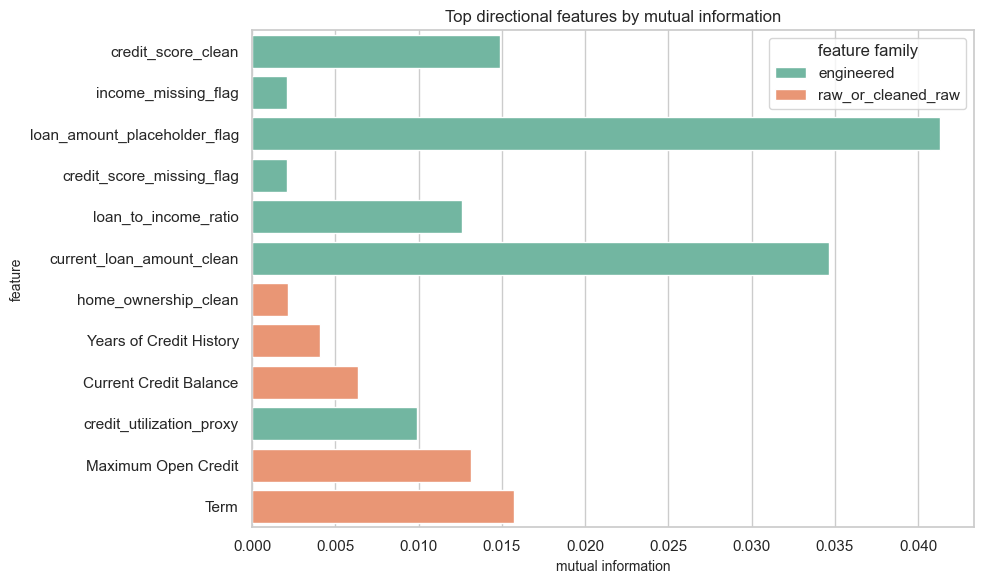

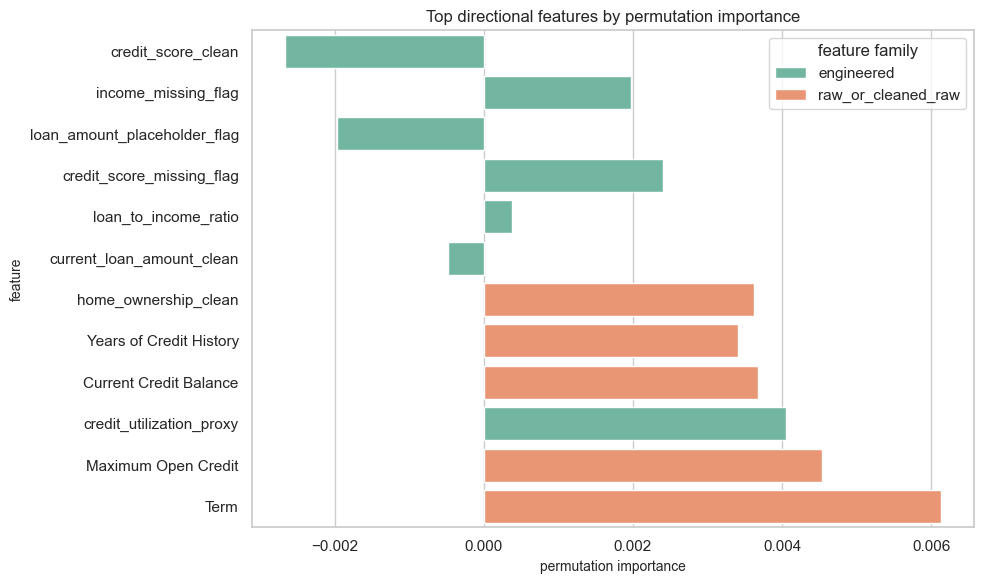

In [13]:
ranking_features = [
    'home_ownership_clean',
    'Annual Income',
    'Years in current job',
    'Tax Liens',
    'Number of Open Accounts',
    'Years of Credit History',
    'Maximum Open Credit',
    'Number of Credit Problems',
    'Months since last delinquent',
    'Bankruptcies',
    'Purpose',
    'Term',
    'Current Credit Balance',
    'Monthly Debt',
    'credit_score_clean',
    'current_loan_amount_clean',
    'job_tenure_years',
    'monthly_dti',
    'credit_utilization_proxy',
    'loan_to_income_ratio',
    'loan_amount_placeholder_flag',
    'income_missing_flag',
    'credit_score_missing_flag',
    'delinquency_missing_flag'
]

categorical_features = ['home_ownership_clean', 'Years in current job', 'Purpose', 'Term']
engineered_features = {
    'credit_score_clean',
    'current_loan_amount_clean',
    'job_tenure_years',
    'monthly_dti',
    'credit_utilization_proxy',
    'loan_to_income_ratio',
    'loan_amount_placeholder_flag',
    'income_missing_flag',
    'credit_score_missing_flag',
    'delinquency_missing_flag'
}

analysis_input = eda_df[ranking_features + [TARGET]].copy()
numeric_features = [col for col in ranking_features if col not in categorical_features]

analysis_input[numeric_features] = analysis_input[numeric_features].apply(pd.to_numeric, errors='coerce')
analysis_input[numeric_features] = analysis_input[numeric_features].fillna(analysis_input[numeric_features].median())
analysis_input[categorical_features] = analysis_input[categorical_features].fillna('Missing')

X_encoded = pd.get_dummies(analysis_input[ranking_features], columns=categorical_features, drop_first=False)
y = analysis_input[TARGET]

discrete_mask = np.array([X_encoded[col].nunique() <= 10 for col in X_encoded.columns])
mi_scores = mutual_info_classif(X_encoded, y, discrete_features=discrete_mask, random_state=RANDOM_STATE)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE
)

rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=RANDOM_STATE,
    n_jobs=1
)
rf.fit(X_train, y_train)

perm = permutation_importance(
    rf,
    X_valid,
    y_valid,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

encoded_importance = pd.DataFrame({
    'encoded_feature': X_encoded.columns,
    'mi_score': mi_scores,
    'permutation_importance': perm.importances_mean
})

def get_source_feature(encoded_name):
    if encoded_name in numeric_features:
        return encoded_name
    for feature in categorical_features:
        prefix = f'{feature}_'
        if encoded_name.startswith(prefix):
            return feature
    return encoded_name

encoded_importance['source_feature'] = encoded_importance['encoded_feature'].apply(get_source_feature)
importance_summary = (
    encoded_importance.groupby('source_feature', as_index=False)
    .agg(
        mi_score=('mi_score', 'max'),
        permutation_importance=('permutation_importance', 'max')
    )
)

importance_summary['feature_family'] = np.where(
    importance_summary['source_feature'].isin(engineered_features),
    'engineered',
    'raw_or_cleaned_raw'
)
importance_summary['mi_rank'] = importance_summary['mi_score'].rank(ascending=False, method='dense')
importance_summary['perm_rank'] = importance_summary['permutation_importance'].rank(ascending=False, method='dense')
importance_summary['combined_rank'] = importance_summary['mi_rank'] + importance_summary['perm_rank']
importance_summary = importance_summary.sort_values(['combined_rank', 'mi_score', 'permutation_importance'])

cut_1 = importance_summary['combined_rank'].quantile(0.33)
cut_2 = importance_summary['combined_rank'].quantile(0.66)
importance_summary['signal_strength'] = np.select(
    [
        importance_summary['combined_rank'] <= cut_1,
        importance_summary['combined_rank'] <= cut_2
    ],
    [
        'high',
        'medium'
    ],
    default='directional'
)

display(importance_summary.round(4))

top_plot = importance_summary.head(12).sort_values('combined_rank', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_plot, x='mi_score', y='source_feature', hue='feature_family', dodge=False)
plt.title('Top directional features by mutual information')
plt.xlabel('mutual information')
plt.ylabel('feature')
plt.legend(title='feature family')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=top_plot, x='permutation_importance', y='source_feature', hue='feature_family', dodge=False)
plt.title('Top directional features by permutation importance')
plt.xlabel('permutation importance')
plt.ylabel('feature')
plt.legend(title='feature family')
plt.tight_layout()
plt.show()


In [14]:
caution_notes = {
    'home_ownership_clean': 'Potential socioeconomic proxy; review fairness metrics and adverse-action explanation coverage.',
    'Years in current job': 'Employment stability can proxy broader socioeconomic patterns; document why it is used.',
    'Months since last delinquent': 'More than half the values are missing; use with a missingness flag rather than trusting an imputed standalone value.',
    'current_loan_amount_clean': 'Only use the cleaned amount, never the raw placeholder value.',
    'loan_amount_placeholder_flag': 'This may capture process behavior or policy overrides rather than pure borrower risk.',
    'credit_score_clean': 'Use the cleaned score only because the raw field mixes scaled and unscaled values.',
    'income_missing_flag': 'Missingness may reflect operational data collection gaps rather than customer creditworthiness.',
    'credit_score_missing_flag': 'Missingness may reflect bureau pull availability or documentation quality.',
    'delinquency_missing_flag': 'Interpret as missing bureau recency information, not as evidence of no delinquency.'
}

consolidated_importance = importance_summary.copy()
consolidated_importance['caution_note'] = consolidated_importance['source_feature'].map(caution_notes).fillna(
    'Standard model monitoring and business validation still apply.'
)

display(
    consolidated_importance[
        ['source_feature', 'feature_family', 'mi_score', 'permutation_importance', 'signal_strength', 'caution_note']
    ].round(4)
)


,source_feature,feature_family,mi_score,permutation_importance,signal_strength,caution_note
10,Term,raw_or_cleaned_raw,0.016,0.006,high,Standard model monitoring and business validat...
3,Maximum Open Credit,raw_or_cleaned_raw,0.013,0.004,high,Standard model monitoring and business validat...
15,credit_utilization_proxy,engineered,0.010,0.004,high,Standard model monitoring and business validat...
2,Current Credit Balance,raw_or_cleaned_raw,0.006,0.004,high,Standard model monitoring and business validat...
18,home_ownership_clean,raw_or_cleaned_raw,0.002,0.004,high,Potential socioeconomic proxy; review fairness...
12,Years of Credit History,raw_or_cleaned_raw,0.004,0.003,high,Standard model monitoring and business validat...
16,current_loan_amount_clean,engineered,0.035,-0.001,high,"Only use the cleaned amount, never the raw pla..."
14,credit_score_missing_flag,engineered,0.002,0.002,high,Missingness may reflect bureau pull availabili...
22,loan_to_income_ratio,engineered,0.013,0.000,high,Standard model monitoring and business validat...
21,loan_amount_placeholder_flag,engineered,0.041,-0.002,medium,This may capture process behavior or policy ov...
